In [1]:
import pandas as pd
import numpy as np
from IPython.display import clear_output
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MeanShift
import multiprocessing

from PBR import PBR
from Reaction import Reaction
from KineticModel import KineticModel

In [2]:
from models_FTS.components import parafins, olefins, others

In [3]:
reconciled_data = pd.read_pickle('reconciled_data.pkl')

kinetic_data = reconciled_data.loc[reconciled_data.CINÉTICA == True]

X = kinetic_data[['T_R_C']]
clustering = MeanShift(bandwidth=2).fit(X)

kinetic_data['cluster'] = clustering.labels_

cluster_set = list(set(kinetic_data.cluster))

index_clusters = kinetic_data.groupby('cluster').T_R_C.mean().sort_values().index.values

val_clusters = index_clusters[[2, 4]]
test_clusters = index_clusters[[6]]
train_clusters = index_clusters[[0,1,3,5]]

loc_validation = kinetic_data['cluster'].isin(val_clusters)
loc_training =  kinetic_data['cluster'].isin(train_clusters)
loc_test = kinetic_data['cluster'].isin(test_clusters)

idx_validation = loc_validation.loc[loc_validation].index
idx_training = loc_training.loc[loc_training].index
idx_test = loc_test.loc[loc_test].index

kinetic_data['training'] = loc_training

In [4]:
loc_validation = kinetic_data['cluster'].isin(val_clusters)
loc_training =  kinetic_data['cluster'].isin(train_clusters)
loc_test = kinetic_data['cluster'].isin(test_clusters)

idx_validation = loc_validation.loc[loc_validation].index
idx_training = loc_training.loc[loc_training].index
idx_test = loc_test.loc[loc_test].index

kinetic_data['training'] = loc_training

In [5]:
data_for_simulation = pd.read_pickle('data_for_simulation.pkl')

In [6]:
def solve_ODEs(data, model_name, param_dict, quantile):
    results_list = []
    unique_indices = data['index'].unique()
    for i in unique_indices:
        data_i = data.loc[data['index'] == i]
        print(f'Quantile: {quantile}')
        print(f'Model: {model_name}')
        print(f'Index {i} of {unique_indices.max()}')
        clear_output(wait = True)
        F0 = data_i['F_H2_e_mol_s'].mean() + data_i['F_CO_e_mol_s'].mean()
    
        H2_CO = data_i['H2_CO'].mean()
        x_CO = 1 / ( 1 + H2_CO )
        x_H2 = 1 - x_CO
    
        # create reactor object
        T0 = (data_i['T_R_K'].mean(), 'K')
        x0 = {
                          'carbon monoxide': x_CO,
                          'hydrogen' : x_H2,
                      }
        reactor = PBR(T0 = T0, 
                      P0 = (data_i['P_abs_Pa'].mean(), 'Pa'), 
                      x0 = x0, 
                      F0 = (F0, 'mol/s'),
                      isothermal = True, 
                      ergun = False,
                      WT = (data_i['m_cat_g'].mean(), 'g'), 
                      W_steps = 50,
                      U = (300, 'W/m2/K'),
                      D = (7, 'mm'),
                      Dp = (0.1725, 'mm'),
                      pellet_density = (2530, 'kg/m3'),
                      Ta = T0,
                      liquid_phase = False,
                      units = 'SI',
                      solver_method = 'BDF',
                      rtol = 1e-5, atol = 1e-7,
                      calculate_equilibrium = False,
                      equilibrium_obj_fun_tolerance = 1e-12,
                      log = True,
                     )
    
        match model_name:
            case 'PowerLaw':
                from models_FTS.PowerLaw         import PowerLaw
                PowerLaw = PowerLaw()
                PowerLaw.kin_param_dict = param_dict
                reactor.add_model(PowerLaw)
            case 'Yates':
                from models_FTS.Yates            import Yates
                Yates = Yates()
                Yates.kin_param_dict = param_dict
                reactor.add_model(Yates)
            case 'Botes':
                from models_FTS.Botes            import Botes
                Botes = Botes()
                Botes.kin_param_dict = param_dict
                reactor.add_model(Botes)
            case 'Ojeda':
                from models_FTS.Ojeda            import Ojeda
                Ojeda = Ojeda()
                Ojeda.kin_param_dict = param_dict
                reactor.add_model(Ojeda)
            case 'Mousavi':
                from models_FTS.Mousavi_C1_C2_Emod          import Mousavi
                Mousavi = Mousavi()
                Mousavi.kin_param_dict = param_dict
                reactor.add_model(Mousavi)
            case 'PowerLaw2':
                from models_FTS.PowerLaw2        import PowerLaw2
                PowerLaw2 = PowerLaw2()
                PowerLaw2.kin_param_dict = param_dict
                reactor.add_model(PowerLaw2)
        reactor.solve()
        # print(f'Params: {reactor.model.kin_param_dict}')
    
        sol_df = reactor.sol_dfs[model_name]
    
        F_H2_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'hydrogen')].value.values[-1]
        F_CO_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'carbon monoxide')].value.values[-1]
        F_H2O_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'water')].value.values[-1]
        F_CO2_out_model = sol_df.loc[(sol_df.W == sol_df.W.max()) & (sol_df.variable == 'carbon dioxide')].value.values[-1]

        for component in parafins:
            data_i.loc[data_i.comp_name == component, f'Fout_{model_name}_{quantile}'] = sol_df.loc[
                (sol_df.W == sol_df.W.max()) & (sol_df.variable == component)].value.values[-1]
        for component in olefins:
            data_i.loc[data_i.comp_name == component, f'Fout_{model_name}_{quantile}'] = sol_df.loc[
                (sol_df.W == sol_df.W.max()) & (sol_df.variable == component)].value.values[-1]
    
        data_i.loc[data_i.comp_name == 'hydrogen', f'Fout_{model_name}_{quantile}']  = F_H2_out_model
        data_i.loc[data_i.comp_name == 'carbon monoxide', f'Fout_{model_name}_{quantile}']  = F_CO_out_model
        data_i.loc[data_i.comp_name == 'water', f'Fout_{model_name}_{quantile}']  = F_H2O_out_model
        data_i.loc[data_i.comp_name == 'carbon dioxide', f'Fout_{model_name}_{quantile}']  = F_CO2_out_model

        results_list.append(data_i)
    data = pd.concat(results_list, ignore_index=True)
    return data

In [7]:
params_df = pd.read_pickle('bootstrap_results.pkl')
params_df_C2Hx = pd.read_pickle('bootstrap_results_C2Hx.pkl')
params_df_CH4 = pd.read_pickle('bootstrap_results_CH4.pkl')
params_df_WGS = pd.read_pickle('bootstrap_results_WGS.pkl')

In [8]:
def build_params_df(bootstrap_model_results, params_names):
    params = bootstrap_model_results.params
    params = np.stack(params.values)
    params = pd.DataFrame(params, columns = params_names)
    return params

PowerLaw_params = build_params_df(params_df.loc[params_df.model == 'PowerLaw'],
                               ('A_HCs', 'E_HCs', 'a', 'b'))

Yates_params = build_params_df(params_df.loc[params_df.model == 'Yates'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs'))

Botes_params = build_params_df(params_df.loc[params_df.model == 'Botes'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs'))

Ojeda_params = build_params_df(params_df.loc[params_df.model == 'Ojeda'],
                               ('k_ads', 'H_ads', 'A_HCs_1', 'E_HCs_1', 'A_HCs_2', 'E_HCs_2'))

Mousavi_params = build_params_df(params_df.loc[params_df.model == 'Mousavi'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs'))

PowerLaw2_params = build_params_df(params_df.loc[params_df.model == 'PowerLaw2'],
                               ('k_ads', 'H_ads', 'A_HCs', 'E_HCs', 'a', 'b', 'c'))

WGS_params = build_params_df(params_df_WGS,
                               ('A_WGS', 'E_WGS', 'a_WGS', 'b_WGS'))

C1_params = build_params_df(params_df_CH4,
                               ('E_C1',))

C2_params = build_params_df(params_df_C2Hx,
                               ('E_C2',))

def build_median_IQR_df(params_df):
    median = params_df.median()
    minimum = params_df.quantile(0.05)
    maximum = params_df.quantile(0.95)
    return pd.DataFrame((minimum, median, maximum), index = ['min', 'median', 'max'])

PowerLaw_median_IQR = build_median_IQR_df(PowerLaw_params)
Yates_median_IQR = build_median_IQR_df(Yates_params)
Botes_median_IQR = build_median_IQR_df(Botes_params)
Ojeda_median_IQR = build_median_IQR_df(Ojeda_params)
Mousavi_median_IQR = build_median_IQR_df(Mousavi_params)
PowerLaw2_median_IQR = build_median_IQR_df(PowerLaw2_params)

In [9]:
C1_params

,E_C1
0,142347.086519
1,143461.414799
2,143564.537838
3,142070.025951
4,142328.670844
...,...
995,142198.736668
996,142480.645999
997,142938.636467
998,143029.761240


In [10]:
PowerLaw_median_IQR

,A_HCs,E_HCs,a,b
min,1.275371,31590.346993,-0.783361,0.144695
median,4.416469,39944.928292,-0.682816,0.201062
max,15.486259,47498.425215,-0.592146,0.252791


In [11]:
params_df_C2Hx

,level_0,index,iteration,run,params,success,nfev,message,obj_f_val_training_data,sum_residuals
0,0,0,0,0,[152475.48080980778],True,64,Optimization terminated successfully.,1.814865e-14,-3.085715e-08
1,1,1,1,0,[154246.14191055298],True,64,Optimization terminated successfully.,1.761142e-14,4.123530e-07
2,2,2,2,0,[153774.85379576683],True,64,Optimization terminated successfully.,1.603031e-14,3.110065e-07
3,3,3,3,0,[152810.06462872028],True,66,Optimization terminated successfully.,1.637345e-14,6.691056e-08
4,4,4,4,0,[153554.97375130653],True,66,Optimization terminated successfully.,1.561760e-14,2.599302e-07
...,...,...,...,...,...,...,...,...,...,...
995,995,245,245,3,[152175.55731534958],True,64,Optimization terminated successfully.,2.073846e-14,-1.249591e-07
996,996,246,246,3,[153235.53748428822],True,66,Optimization terminated successfully.,1.548454e-14,1.810912e-07
997,997,247,247,3,[153174.84714090824],True,66,Optimization terminated successfully.,1.553069e-14,1.654631e-07
998,998,248,248,3,[152570.86798548698],True,64,Optimization terminated successfully.,1.753221e-14,-2.232396e-09


In [12]:
params_df

,level_0,index,model,iteration,run,params,success,nfev,message,obj_f_val_training_data,sum_residuals
0,0,0,PowerLaw,0,0,"[6.327396772637107, 42306.01502676773, -0.6664...",True,570,Optimization terminated successfully.,8.012106e-11,1.087949e-05
1,1,1,Yates,0,0,"[6.5329393598615374e-06, 290.97896475433754, 2...",True,780,Optimization terminated successfully.,4.199441e-10,-5.409549e-05
2,2,2,Botes,0,0,"[0.013486725780966493, 0.013548325598392495, 5...",True,1044,Optimization terminated successfully.,3.340107e-10,-3.081546e-05
3,3,3,Ojeda,0,0,"[3.147386858567878e-06, 3.377314237188716e-08,...",True,830,Optimization terminated successfully.,1.530138e-10,7.508603e-06
4,4,4,PowerLaw2,0,0,"[0.04759487937092078, 5.177084877086058e-05, 1...",True,560,Optimization terminated successfully.,1.403563e-10,7.621596e-06
...,...,...,...,...,...,...,...,...,...,...,...
6043,6043,247,Yates,41,23,"[0.0006589740420325657, -77191.96637486634, 0....",False,6400,Maximum number of function evaluations has bee...,4.604518e-10,-3.634850e-05
6044,6044,248,Botes,41,23,"[75.17447621780576, -92.78055856892317, 225856...",False,6400,Maximum number of function evaluations has bee...,3.389145e-10,-3.994583e-05
6045,6045,249,Ojeda,41,23,"[6.095082980094935e-06, -1.5445075111912152e-0...",True,1415,Optimization terminated successfully.,1.930047e-10,-4.162234e-06
6046,6046,250,PowerLaw2,41,23,"[0.09128784022101802, 0.00015320952765658213, ...",True,822,Optimization terminated successfully.,1.697896e-10,-2.855965e-07


In [13]:
params_df_all = params_df

In [14]:
model_names = [
    'PowerLaw', 
    'Yates', 
    'Botes', 'Ojeda', 'Mousavi',
    'PowerLaw2'
]

In [15]:
for model in model_names:
    params_df_all

In [16]:
def make_params_dict(model, params, p_WGS, p_CH4, p_C2Hx):
    match model:
        case 'PowerLaw':
            return {
                    'A_HCs': params[0],
                    'E_HCs': params[1],
                    'a': params[2],
                    'b': params[3],
                    'A_WGS': p_WGS[0],
                    'E_WGS': p_WGS[1],
                    'a_WGS': p_WGS[2],
                    'b_WGS': p_WGS[3]}
        case 'Yates':
            return {
                    'k_ads': params[0],
                    'H_ads': params[1],
                    'A_HCs': params[2],
                    'E_HCs': params[3],
                    'A_WGS': p_WGS[0],
                    'E_WGS': p_WGS[1],
                    'a_WGS': p_WGS[2],
                    'b_WGS': p_WGS[3]}
        case 'Botes':
            return {
                    'k_ads': params[0],
                    'H_ads': params[1],
                    'A_HCs': params[2],
                    'E_HCs': params[3],
                    'A_WGS': p_WGS[0],
                    'E_WGS': p_WGS[1],
                    'a_WGS': p_WGS[2],
                    'b_WGS': p_WGS[3]}
        case 'Ojeda':
            return {
                    'k_ads': params[0],
                    'H_ads': params[1],
                    'A_HCs_1': params[2],
                    'E_HCs_1': params[3],
                    'A_HCs_2': params[4],
                    'E_HCs_2': params[5],
                    'A_WGS': p_WGS[0],
                    'E_WGS': p_WGS[1],
                    'a_WGS': p_WGS[2],
                    'b_WGS': p_WGS[3]}
        case 'Mousavi':
            return {
                    'k_ads': params[0],
                    'H_ads': params[1],
                    'A_HCs': params[2],
                    'E_HCs': params[3],
                    'A_WGS': p_WGS[0],
                    'E_WGS': p_WGS[1],
                    'a_WGS': p_WGS[2],
                    'b_WGS': p_WGS[3],
                    'E_C1' : p_CH4[0],
                    'E_C2' : p_C2Hx[0]}
        case 'PowerLaw2':
            return {
                    'k_ads': params[0],
                    'H_ads': params[1],
                    'A_HCs': params[2],
                    'E_HCs': params[3],
                    'a': params[4],
                    'b': params[5],
                    'c': params[6],
                    'A_WGS': p_WGS[0],
                    'E_WGS': p_WGS[1],
                    'a_WGS': p_WGS[2],
                    'b_WGS': p_WGS[3]}

In [17]:
for model in model_names:
    params_df_model = params_df.loc[params_df.model == model]
    
    target_value_low = params_df_model['sum_residuals'].quantile(0.25)
    target_value_high = params_df_model['sum_residuals'].quantile(0.75)
    
    params_low = params_df_model.loc[params_df_model['sum_residuals'].sub(target_value_low).abs().idxmin(), 'params']
    params_high = params_df_model.loc[params_df_model['sum_residuals'].sub(target_value_high).abs().idxmin(), 'params']

    target_value_WGS_low = params_df_WGS['sum_residuals'].quantile(0.25)
    target_value_WGS_high = params_df_WGS['sum_residuals'].quantile(0.75)
    
    params_WGS_low = params_df_WGS.loc[params_df_WGS['sum_residuals'].sub(target_value_WGS_low).abs().idxmin(), 'params']
    params_WGS_high = params_df_WGS.loc[params_df_WGS['sum_residuals'].sub(target_value_WGS_high).abs().idxmin(), 'params']

    target_value_CH4_low = params_df_CH4['sum_residuals'].quantile(0.25)
    target_value_CH4_high = params_df_CH4['sum_residuals'].quantile(0.75)
    
    params_CH4_low = params_df_CH4.loc[params_df_CH4['sum_residuals'].sub(target_value_CH4_low).abs().idxmin(), 'params']
    params_CH4_high = params_df_CH4.loc[params_df_CH4['sum_residuals'].sub(target_value_CH4_high).abs().idxmin(), 'params']

    target_value_C2Hx_low = params_df_C2Hx['sum_residuals'].quantile(0.25)
    target_value_C2Hx_high = params_df_C2Hx['sum_residuals'].quantile(0.75)
    
    params_C2Hx_low = params_df_C2Hx.loc[params_df_C2Hx['sum_residuals'].sub(target_value_C2Hx_low).abs().idxmin(), 'params']
    params_C2Hx_high = params_df_C2Hx.loc[params_df_C2Hx['sum_residuals'].sub(target_value_C2Hx_high).abs().idxmin(), 'params']

    data_for_simulation = solve_ODEs(data_for_simulation, 
                                     model, 
                                     make_params_dict(model, params_low, params_WGS_low, params_CH4_low, params_C2Hx_low), 
                                     'low')

    data_for_simulation = solve_ODEs(data_for_simulation, 
                                     model, 
                                     make_params_dict(model, params_high, params_WGS_high, params_CH4_high, params_C2Hx_high), 
                                     'high')

data_for_simulation.to_pickle('data_for_simulation_bootstraped.pkl')
data_for_simulation.to_excel('data_for_simulation_bootstraped.ods')

Quantile: high
Model: PowerLaw2
Index 305 of 305


In [18]:
data_for_simulation = pd.read_pickle('data_for_simulation_bootstraped.pkl')

In [19]:
molar_mass_dict = {
 '$\\mathrm{H_2}$':           2,
 '$\\mathrm{CH_4}$':          16,
 '$\\mathrm{CO}$':            12+16,
 '$\\mathrm{CO_2}$':          44,
 '$\\mathrm{C_2 H_4}$':        2*12 + 4,
 '$\\mathrm{C_2 H_6}$':        2*12 + 6,
 '$\\mathrm{C_3 H_8}$':        3*12 + 8,
 '$\\mathrm{H_2 O}$':         18,
 '$\\mathrm{C_9 H_{20}}$':     9*12 + 20,
 '$\\mathrm{C_{10} H_{22}}$': 10*12 + 22,
 '$\\mathrm{C_{11} H_{24}}$': 11*12 + 24,
 '$\\mathrm{C_{12} H_{26}}$': 12*12 + 26,
 '$\\mathrm{C_{13} H_{28}}$': 13*12 + 28,
 '$\\mathrm{C_{14} H_{30}}$': 14*12 + 30,
 '$\\mathrm{C_{15} H_{32}}$': 15*12 + 32,
 '$\\mathrm{C_{16} H_{34}}$': 16*12 + 34,
 '$\\mathrm{C_{17} H_{36}}$': 17*12 + 36,
 '$\\mathrm{C_{18} H_{38}}$': 18*12 + 38,
 '$\\mathrm{C_{19} H_{40}}$': 19*12 + 40,
 '$\\mathrm{C_{20} H_{42}}$': 20*12 + 42,
 '$\\mathrm{C_{21} H_{44}}$': 21*12 + 44,
 '$\\mathrm{C_{22} H_{46}}$': 22*12 + 46,
 '$\\mathrm{C_{23} H_{48}}$': 23*12 + 48,
 '$\\mathrm{C_{24} H_{50}}$': 24*12 + 50,
 '$\\mathrm{C_{25} H_{52}}$': 25*12 + 52,
 '$\\mathrm{C_{26} H_{54}}$': 26*12 + 54,
 '$\\mathrm{C_{27} H_{56}}$': 27*12 + 56,
 '$\\mathrm{C_{28} H_{58}}$': 28*12 + 58,
 '$\\mathrm{C_{29} H_{60}}$': 29*12 + 60,
 '$\\mathrm{C_{30} H_{62}}$': 30*12 + 62,
 '$\\mathrm{C_9 H_{18}}$':     9*12 + 18,
 '$\\mathrm{C_{10} H_{20}}$': 10*12 + 20,
 '$\\mathrm{C_{11} H_{22}}$': 11*12 + 22,
 '$\\mathrm{C_{12} H_{24}}$': 12*12 + 24,
 '$\\mathrm{C_{13} H_{26}}$': 13*12 + 26,
 '$\\mathrm{C_{14} H_{28}}$': 14*12 + 28,
 '$\\mathrm{C_{15} H_{30}}$': 15*12 + 30,
 '$\\mathrm{C_{16} H_{32}}$': 16*12 + 32,
 '$\\mathrm{C_{17} H_{34}}$': 17*12 + 34,
 '$\\mathrm{C_{18} H_{36}}$': 18*12 + 36}

In [20]:
data_for_simulation['MM (g/mol)'] = data_for_simulation.component.map(molar_mass_dict)

In [21]:
data_for_simulation['m_out_exp (g/d)'] = 86400 * data_for_simulation['MM (g/mol)']*data_for_simulation.Fout_exp

In [22]:
for model in model_names:
    data_for_simulation[f'm_out_{model} (g/d)'] = (
        data_for_simulation['MM (g/mol)']*data_for_simulation[f'Fout_{model}']
    ) * 86400

In [23]:
for model in model_names:
    data_for_simulation[f'm_out_{model}_low (g/d)'] = (
        data_for_simulation['MM (g/mol)'] * data_for_simulation[f'Fout_{model}_low']
    ) * 86400
    data_for_simulation[f'm_out_{model}_high (g/d)'] = (
        data_for_simulation['MM (g/mol)'] * data_for_simulation[f'Fout_{model}_high']
    ) * 86400

    data_for_simulation[f'sigma_m_out_{model}_low (g/d)'] = abs(
        data_for_simulation[f'm_out_{model} (g/d)'] - data_for_simulation[f'm_out_{model}_low (g/d)']
    )
    data_for_simulation[f'sigma_m_out_{model}_high (g/d)'] = abs(
        data_for_simulation[f'm_out_{model}_high (g/d)'] - data_for_simulation[f'm_out_{model} (g/d)']
    )

    # to clip error bars to be always > 0
    loc_lwr_zero = ((data_for_simulation[f'm_out_{model} (g/d)'] - data_for_simulation[f'sigma_m_out_{model}_low (g/d)']) <= 0)
    data_for_simulation.loc[loc_lwr_zero, f'sigma_m_out_{model}_low (g/d)'] = data_for_simulation.loc[loc_lwr_zero, f'm_out_{model} (g/d)'].clip(lower = 0)

    loc_lwr_zero = ((data_for_simulation[f'm_out_{model} (g/d)'] - data_for_simulation[f'sigma_m_out_{model}_high (g/d)']) <= 0)
    data_for_simulation.loc[loc_lwr_zero, f'sigma_m_out_{model}_high (g/d)'] = data_for_simulation.loc[loc_lwr_zero, f'm_out_{model} (g/d)'].clip(lower = 0)
    
    data_for_simulation[f'sigma_m_out_{model} (g/d)'] = (
        data_for_simulation[f'sigma_m_out_{model}_low (g/d)']
        +
        data_for_simulation[f'sigma_m_out_{model}_high (g/d)']
    ) / 2

In [24]:
plot_mass_flows = data_for_simulation.groupby(['index', 'leg_labels']).sum()

In [25]:
plot_mass_flows['sum m_out_exp (g/d)'] = data_for_simulation.groupby(['index']).sum()['m_out_exp (g/d)']

plot_mass_flows['omega_n_exp'] = plot_mass_flows['m_out_exp (g/d)'] / plot_mass_flows['sum m_out_exp (g/d)'] 

plot_mass_flows['sigma_m_out_exp (g/d)'] = (
    ( plot_mass_flows['sum m_out_exp (g/d)'] * 0.001  ) ** 2
    +
    ( plot_mass_flows['omega_n_exp'] * plot_mass_flows['sum m_out_exp (g/d)'] * 0.05 ) ** 2
) ** ( 1 / 2 )

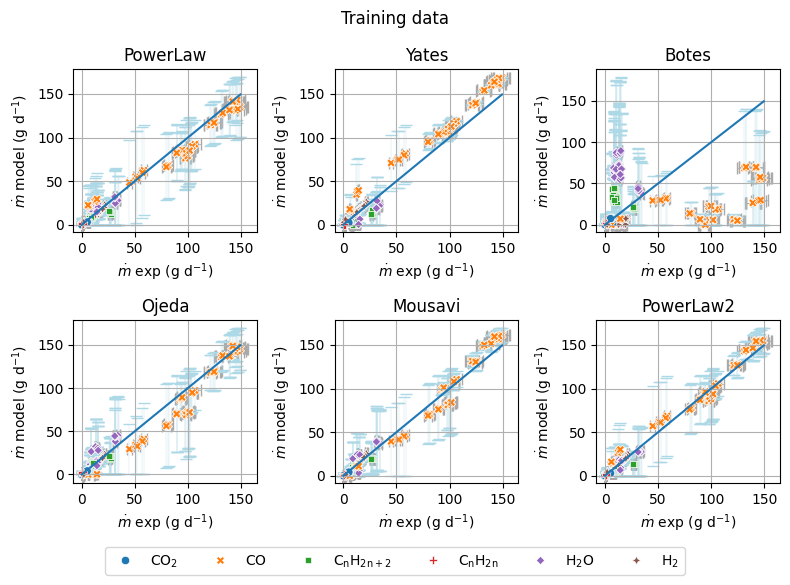

In [26]:
fig, axs = plt.subplots(2, 3, figsize = (8, 5.5))
flat_axs = axs.flatten()

max_xy = data_for_simulation['m_out_exp (g/d)'].max()

# flat_axs[4].errorbar(
#         x=plot_mass_flows.loc[idx_training, 'm_out_exp (g/d)'], 
#         y=plot_mass_flows.loc[idx_training, 'm_out_Mousavi (g/d)'], 
#         yerr=plot_mass_flows.loc[idx_training, 'sigma_m_out_Mousavi_mean (g/d)'], 
#         fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
#         ecolor="darkgray",     # Error bar line color
#         capsize=4,          # Width of the caps at the end of the error bars
#         zorder=1,
#         lw = 0.5,
#     )

for i, model in enumerate(model_names):
    flat_axs[i].errorbar(
        x=plot_mass_flows.loc[idx_training, 'm_out_exp (g/d)'], 
        y=plot_mass_flows.loc[idx_training, f'm_out_{model} (g/d)'], 
        xerr=plot_mass_flows.loc[idx_training, 'sigma_m_out_exp (g/d)'], 
        fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
        ecolor="darkgray",     # Error bar line color
        capsize=4,          # Width of the caps at the end of the error bars
        zorder=1,
        lw = 0.5,
    )

    flat_axs[i].errorbar(
        x=plot_mass_flows.loc[idx_training, 'm_out_exp (g/d)'], 
        y=plot_mass_flows.loc[idx_training, f'm_out_{model} (g/d)'], 
        # yerr=plot_mass_flows.loc[idx_training, f'sigma_m_out_{model} (g/d)'], 
        yerr = plot_mass_flows.loc[idx_training, [f'sigma_m_out_{model}_low (g/d)', f'sigma_m_out_{model}_high (g/d)']].to_numpy().T,
        fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
        ecolor="lightblue",     # Error bar line color
        capsize=4,          # Width of the caps at the end of the error bars
        zorder=1,
        lw = 0.2,
    )
    
    sns.scatterplot(data = plot_mass_flows.loc[idx_training,:], 
                    x = 'm_out_exp (g/d)', y = f'm_out_{model} (g/d)',
                    ax=flat_axs[i],
                    hue = 'leg_labels', style = 'leg_labels',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel(r'$\dot{m}$ model $\mathrm{(g~d^{-1})}$')
    flat_axs[i].set_xlabel(r'$\dot{m}$ exp $\mathrm{(g~d^{-1})}$')
    # flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    # flat_axs[i].set_yscale('log')
    # flat_axs[i].set_xscale('log')
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')
    flat_axs[i].legend().remove()
    # flat_axs[i].set_ylim(-5, None)

handles, labels = flat_axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.06), # Adjust 0.92 to move it up or down
           ncol=6, 
           frameon=True)
fig.suptitle('Training data')
plt.tight_layout()
fig_name = 'figure-m_out_parity_training.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')

In [27]:
plot_mass_flows.to_pickle('plot_mass_flows.pkl')
plot_mass_flows.to_excel('plot_mass_flows.ods')

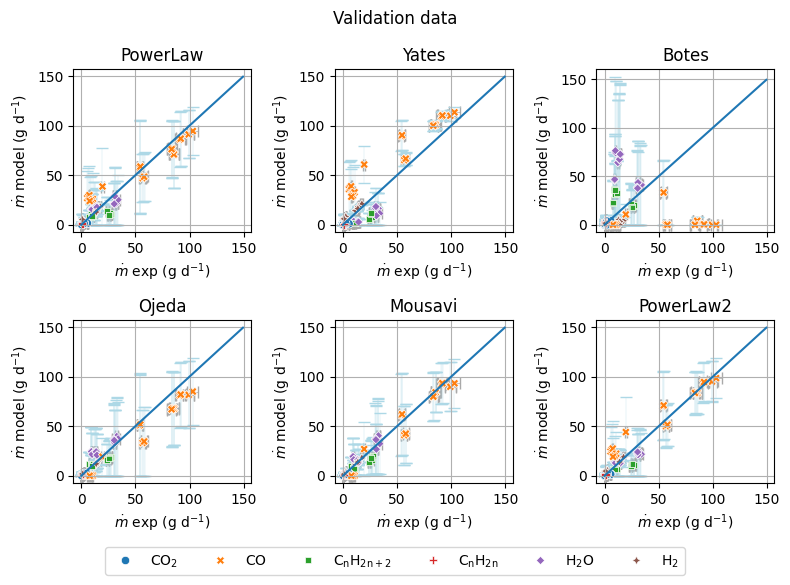

In [28]:
fig, axs = plt.subplots(2, 3, figsize = (8, 5.5))
flat_axs = axs.flatten()

max_xy = data_for_simulation['m_out_exp (g/d)'].max()

# flat_axs[4].errorbar(
#         x=plot_mass_flows.loc[idx_validation, 'm_out_exp (g/d)'], 
#         y=plot_mass_flows.loc[idx_validation, 'm_out_Mousavi (g/d)'], 
#         yerr=plot_mass_flows.loc[idx_validation, 'sigma_m_out_Mousavi_mean (g/d)'], 
#         fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
#         ecolor="darkgray",     # Error bar line color
#         capsize=4,          # Width of the caps at the end of the error bars
#         zorder=1,
#         lw = 0.5,
#     )

for i, model in enumerate(model_names):
    flat_axs[i].errorbar(
        x=plot_mass_flows.loc[idx_validation, 'm_out_exp (g/d)'], 
        y=plot_mass_flows.loc[idx_validation, f'm_out_{model} (g/d)'], 
        xerr=plot_mass_flows.loc[idx_validation, 'sigma_m_out_exp (g/d)'], 
        fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
        ecolor="darkgray",     # Error bar line color
        capsize=4,          # Width of the caps at the end of the error bars
        zorder=1,
        lw = 0.5,
    )

    flat_axs[i].errorbar(
        x=plot_mass_flows.loc[idx_validation, 'm_out_exp (g/d)'], 
        y=plot_mass_flows.loc[idx_validation, f'm_out_{model} (g/d)'], 
        yerr=plot_mass_flows.loc[idx_validation, f'sigma_m_out_{model} (g/d)'], 
        fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
        ecolor="lightblue",     # Error bar line color
        capsize=4,          # Width of the caps at the end of the error bars
        zorder=1,
        lw = 0.2,
    )
    
    sns.scatterplot(data = plot_mass_flows.loc[idx_validation,:], 
                    x = 'm_out_exp (g/d)', y = f'm_out_{model} (g/d)',
                    ax=flat_axs[i],
                    hue = 'leg_labels', style = 'leg_labels',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel(r'$\dot{m}$ model $\mathrm{(g~d^{-1})}$')
    flat_axs[i].set_xlabel(r'$\dot{m}$ exp $\mathrm{(g~d^{-1})}$')
    # flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    # flat_axs[i].set_yscale('log')
    # flat_axs[i].set_xscale('log')
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')
    flat_axs[i].legend().remove()
    # flat_axs[i].set_ylim(-5, None)

handles, labels = flat_axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.06), # Adjust 0.92 to move it up or down
           ncol=6, 
           frameon=True)
fig.suptitle('Validation data')
plt.tight_layout()
fig_name = 'figure-m_out_parity_validation.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')

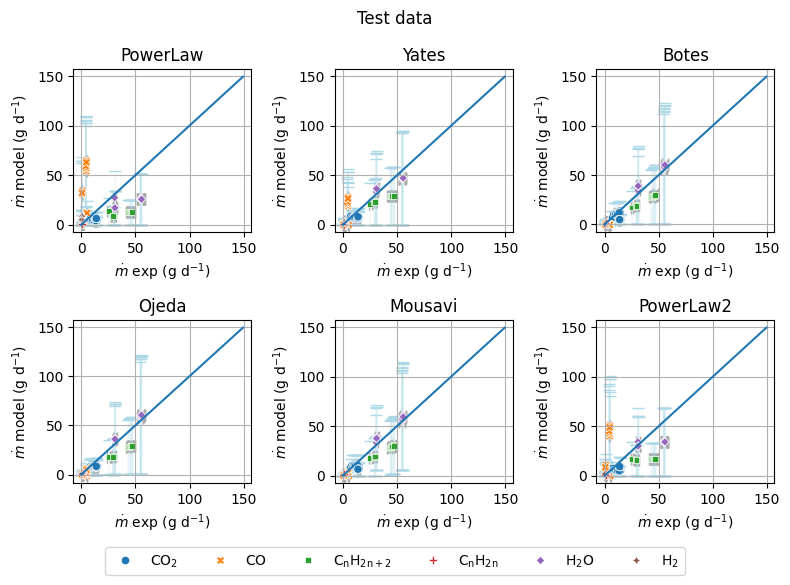

In [29]:
fig, axs = plt.subplots(2, 3, figsize = (8, 5.5))
flat_axs = axs.flatten()

max_xy = data_for_simulation['m_out_exp (g/d)'].max()

# flat_axs[4].errorbar(
#         x=plot_mass_flows.loc[idx_test, 'm_out_exp (g/d)'], 
#         y=plot_mass_flows.loc[idx_test, 'm_out_Mousavi (g/d)'], 
#         yerr=plot_mass_flows.loc[idx_test, 'sigma_m_out_Mousavi_mean (g/d)'], 
#         fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
#         ecolor="darkgray",     # Error bar line color
#         capsize=4,          # Width of the caps at the end of the error bars
#         zorder=1,
#         lw = 0.5,
#     )

for i, model in enumerate(model_names):
    flat_axs[i].errorbar(
        x=plot_mass_flows.loc[idx_test, 'm_out_exp (g/d)'], 
        y=plot_mass_flows.loc[idx_test, f'm_out_{model} (g/d)'], 
        xerr=plot_mass_flows.loc[idx_test, 'sigma_m_out_exp (g/d)'], 
        fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
        ecolor="darkgray",     # Error bar line color
        capsize=4,          # Width of the caps at the end of the error bars
        zorder=1,
        lw = 0.5,
    )

    flat_axs[i].errorbar(
        x=plot_mass_flows.loc[idx_test, 'm_out_exp (g/d)'], 
        y=plot_mass_flows.loc[idx_test, f'm_out_{model} (g/d)'], 
        yerr=plot_mass_flows.loc[idx_test, f'sigma_m_out_{model} (g/d)'], 
        fmt="none",        # 'none' ensures it doesn't redraw line/markers over scatter
        ecolor="lightblue",     # Error bar line color
        capsize=4,          # Width of the caps at the end of the error bars
        zorder=1,
        lw = 0.2,
    )
    
    sns.scatterplot(data = plot_mass_flows.loc[idx_test,:], 
                    x = 'm_out_exp (g/d)', y = f'm_out_{model} (g/d)',
                    ax=flat_axs[i],
                    hue = 'leg_labels', style = 'leg_labels',
                   )
    flat_axs[i].set_title(model)
    flat_axs[i].set_ylabel(r'$\dot{m}$ model $\mathrm{(g~d^{-1})}$')
    flat_axs[i].set_xlabel(r'$\dot{m}$ exp $\mathrm{(g~d^{-1})}$')
    # flat_axs[i].ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
    # flat_axs[i].set_yscale('log')
    # flat_axs[i].set_xscale('log')
    flat_axs[i].plot((0, max_xy), (0, max_xy))
    flat_axs[i].grid('both')
    flat_axs[i].legend().remove()
    # flat_axs[i].set_ylim(-5, None)

handles, labels = flat_axs[0].get_legend_handles_labels()

fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.06), # Adjust 0.92 to move it up or down
           ncol=6, 
           frameon=True)
fig.suptitle('Test data')
plt.tight_layout()
fig_name = 'figure-m_out_parity_test.pdf'
# plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
#             bbox_inches = 'tight')